# Clinical Interpretation of Model Results

This model predicts 30-day hospital readmission risk using structured EHR data.

## Key Drivers of Readmission Risk

Based on feature importance from the XGBoost model:

 - Prior inpatient visits (number_inpatient) were the strongest predictor of readmission risk, suggesting that patients with frequent hospitalizations are at significantly higher risk.
 - Diabetes treatment (diabetesMed) and insulin usage were important predictors, likely reflecting disease severity and complexity of management.
 - Elevated A1C levels (A1Cresult > 8) were associated with increased risk, indicating that poor glycemic control contributes to readmissions.
 - Length of hospital stay (time_in_hospital) was also predictive, with longer stays indicating more severe illness.
 - Age showed nonlinear effects, with older age groups exhibiting higher risk.
 - Clinical Implications

These findings suggest that readmission risk is driven by a combination of:

 - Healthcare utilization patterns (inpatient and emergency visits)
 - Disease severity and management (A1C levels, medications)
 - Patient characteristics (age)

In practice, this type of model could be used to:

 - Identify high-risk patients at discharge
 - Trigger additional follow-up or care coordination
 - Allocate hospital resources more effectively

## Setup and Imports

In [ ]:
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
sns.set(style="whitegrid")

# Warnings
warnings.filterwarnings("ignore")


In [ ]:
# #SQL Access - Used for original project; use if want to connect to own MySQL database

# from sqlalchemy import create_engine
# from urllib.parse import quote_plus
# import os
# from dotenv import load_dotenv

# #Create own .env file with local information
# load_dotenv()

# DB_USER = os.getenv("DB_USER")
# DB_PASSWORD = quote_plus(os.getenv("DB_PASSWORD"))
# DB_HOST = os.getenv("DB_HOST", "localhost")
# DB_PORT = os.getenv("DB_PORT", "3306")
# DB_NAME = os.getenv("DB_NAME", "disease_db")

# engine = create_engine(
#     f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
# )

# print("Engine created successfully")

## Loading Data

In [33]:
df = pd.read_csv("data/diabetic_data.csv")
# df = pd.read_sql("SELECT * FROM disease_db.disease_readmis", engine)
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [34]:
df.shape

(101766, 50)

## Data Overview

This dataset contains patient-level encounter data, including demographics, diagnoses, medications, and hospital utilization metrics.

In [35]:
df.dtypes
df.isna().mean().sort_values(ascending=False).head(10)

max_glu_serum    0.947468
A1Cresult        0.832773
encounter_id     0.000000
nateglinide      0.000000
glimepiride      0.000000
acetohexamide    0.000000
glipizide        0.000000
glyburide        0.000000
tolbutamide      0.000000
pioglitazone     0.000000
dtype: float64

In [36]:
df["readmitted"].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

## Data Cleaning

The `readmitted` column contains hidden formatting characters (`\r`), which must be removed before creating the target variable.

In [37]:
df["readmitted_clean"] = df["readmitted"].astype(str).str.strip()

In [38]:
df["readmitted_clean"].value_counts()

readmitted_clean
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

## Target Variable

We define a binary target for 30-day readmission:
- 1 = readmitted within 30 days (`<30`)
- 0 = otherwise (`>30`, `NO`)

In [39]:
df["readmit_30d"] = df["readmitted_clean"].map({
    "<30": 1,
    ">30": 0,
    "NO": 0
})

In [41]:
df["readmit_30d"].value_counts(normalize=True)

readmit_30d
0    0.888401
1    0.111599
Name: proportion, dtype: float64

## Class Imbalance

The dataset is imbalanced, with approximately 11% positive cases. This will impact model evaluation and requires careful metric selection.

In [19]:
# Class imbalance check
positive_rate = df["readmit_30d"].mean()
print(f"30-day readmission rate: {positive_rate:.2%}")

30-day readmission rate: 11.16%


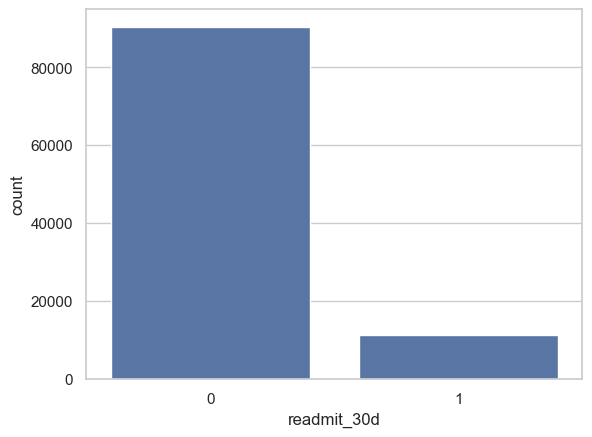

In [42]:
sns.countplot(x="readmit_30d", data=df)
plt.show()

The 30-day readmission rate in the dataset is 11.16%, indicating a moderately imbalanced classification problem. Because the majority of encounters do not result in readmission, traditional accuracy metrics may be misleading. Model performance will therefore be evaluated using ROC-AUC, precision, and recall, with particular attention to recall to ensure that high-risk patients are identified.

## Export Clean Dataset

The cleaned dataset is saved for use in the modeling stage.

In [30]:
df.to_csv("data/diabetes_clean.csv", index=False)

Please switch to '02_modeling.ipynb' for the modeling, evaluating, and interpretation of results part of project.